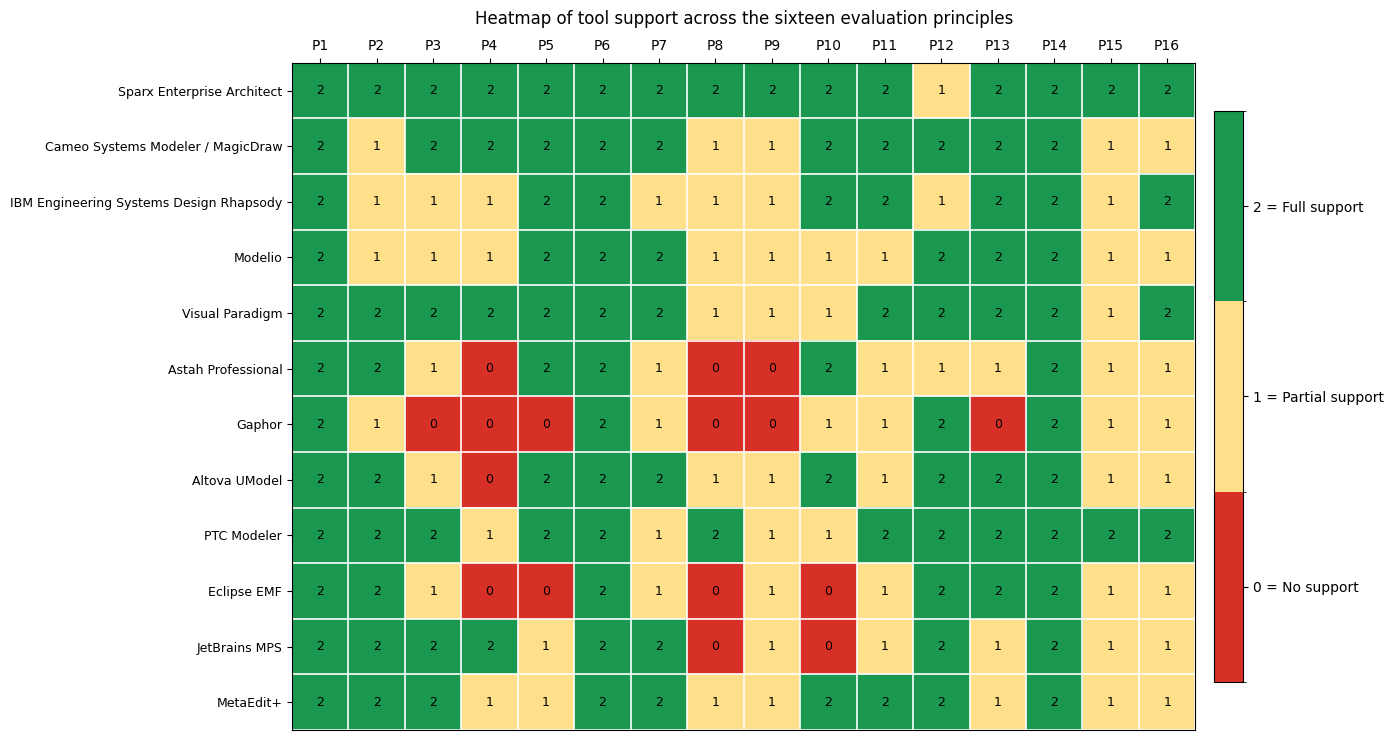

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# =========================================================
# Data: 12 tools x 16 principles (P1..P16)
# Source: your comparative matrix / Table 3 draft
# Scores: 0 = no support, 1 = partial support, 2 = full support
# =========================================================

tools = [
    "Sparx Enterprise Architect",
    "Cameo Systems Modeler / MagicDraw",
    "IBM Engineering Systems Design Rhapsody",
    "Modelio",
    "Visual Paradigm",
    "Astah Professional",
    "Gaphor",
    "Altova UModel",
    "PTC Modeler",
    "Eclipse EMF",
    "JetBrains MPS",
    "MetaEdit+",
]

principles = [f"P{i}" for i in range(1, 17)]

scores = np.array([
    [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2],  # Sparx Enterprise Architect
    [2, 1, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 1],  # Cameo Systems Modeler / MagicDraw
    [2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 2, 2, 1, 2],  # IBM Engineering Systems Design Rhapsody
    [2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1],  # Modelio
    [2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 1, 2],  # Visual Paradigm
    [2, 2, 1, 0, 2, 2, 1, 0, 0, 2, 1, 1, 1, 2, 1, 1],  # Astah Professional
    [2, 1, 0, 0, 0, 2, 1, 0, 0, 1, 1, 2, 0, 2, 1, 1],  # Gaphor
    [2, 2, 1, 0, 2, 2, 2, 1, 1, 2, 1, 2, 2, 2, 1, 1],  # Altova UModel
    [2, 2, 2, 1, 2, 2, 1, 2, 1, 1, 2, 2, 2, 2, 2, 2],  # PTC Modeler
    [2, 2, 1, 0, 0, 2, 1, 0, 1, 0, 1, 2, 2, 2, 1, 1],  # Eclipse EMF
    [2, 2, 2, 2, 1, 2, 2, 0, 1, 0, 1, 2, 1, 2, 1, 1],  # JetBrains MPS
    [2, 2, 2, 1, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2, 1, 1],  # MetaEdit+
])

# =========================================================
# Plot settings
# Discrete 3-level color map because the scoring scheme is ordinal: 0,1,2
# =========================================================

cmap = ListedColormap(["#d73027", "#fee08b", "#1a9850"])  # red, yellow, green
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots(figsize=(14, 7.5))
im = ax.imshow(scores, cmap=cmap, norm=norm, aspect="auto")

# Axis ticks and labels
ax.set_xticks(np.arange(len(principles)))
ax.set_xticklabels(principles, fontsize=10)
ax.set_yticks(np.arange(len(tools)))
ax.set_yticklabels(tools, fontsize=9)

# Put x labels on top if you prefer journal-style matrix layout
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

# Cell annotations
for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        ax.text(
            j, i, str(scores[i, j]),
            ha="center", va="center",
            color="black", fontsize=9
        )

# Gridlines between cells
ax.set_xticks(np.arange(-0.5, len(principles), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(tools), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

# Title
ax.set_title(
    "Heatmap of tool support across the sixteen evaluation principles",
    fontsize=12, pad=28
)

# Colorbar with discrete labels
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2], fraction=0.03, pad=0.02)
cbar.ax.set_yticklabels([
    "0 = No support",
    "1 = Partial support",
    "2 = Full support"
])

plt.tight_layout()

# Save files
plt.savefig("mda_tool_heatmap.png", dpi=300, bbox_inches="tight")
plt.savefig("mda_tool_heatmap.pdf", bbox_inches="tight")

plt.show()